# FLARE to NPZ Conversion and Visualization

This notebook converts FLARE dataset `.nii.gz` files into a unified `.npz` format for testing.

In [1]:
import sys
from pathlib import Path
import os
import numpy as np

# Ensure project root is on sys.path
parent = Path().resolve().parent.parent 
if str(parent) not in sys.path:
    sys.path.append(str(parent))

from data.test_data.flare_to_npz import process_flare_dataset
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices, plot_one_dp

## 1. Process FLARE Dataset

We use the `process_flare_dataset` function to resample images and masks to 1.0mm isotropic resolution (without cropping).

In [3]:
data_dir = "FLARE_2022"
output_name = "FLARE_2022"

if os.path.isdir(data_dir):
    process_flare_dataset(data_dir, output_name)
else:
    print(f"Data directory {data_dir} not found. Please ensure it exists.")


[1/50] Processing FLARE22_Tr_0001 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.64', '0.64') mm → 1.0 mm isotropic ...
  -> Resampled shape: (275, 308, 330)

[2/50] Processing FLARE22_Tr_0002 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.74', '0.74') mm → 1.0 mm isotropic ...
  -> Resampled shape: (268, 324, 380)

[3/50] Processing FLARE22_Tr_0003 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.77', '0.77') mm → 1.0 mm isotropic ...
  -> Resampled shape: (252, 338, 385)

[4/50] Processing FLARE22_Tr_0004 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.73', '0.73') mm → 1.0 mm isotropic ...
  -> Resampled shape: (218, 333, 368)

[5/50] Processing FLARE22_Tr_0005 ...
  Cropping to anatomy (margin=15) ...
  Resampling from spacing ('2.50', '0.77', '0.77') mm → 1.0 mm isotropic ...
  -> Resampled shape: (212, 365, 394)

[6/50] Processing FLARE22_Tr_0006 ...
 

## 2. Load and Visualize

Now we load the generated `.npz` file and visualize a few samples.

In [3]:
npz_path = f"data/test_data/{output_name}.npz"

dg = DataGenerator(DataLoader_npz([npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids
print(f"Loaded IDs: {all_ids}")

sample_id = all_ids[0]
img = dg.dataloader.dataset[sample_id]['image']
mask = dg.dataloader.dataset[sample_id]['segmentations']

print(f"Sample: {sample_id}")
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask[0].shape}")


Loading NPZ dataset(s)…
Loaded 50 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\FLARE_2022.npz

Final dataset size: 50 patients.

Loaded IDs: ['FLARE_2022_FLARE22_Tr_0049', 'FLARE_2022_FLARE22_Tr_0026', 'FLARE_2022_FLARE22_Tr_0040', 'FLARE_2022_FLARE22_Tr_0006', 'FLARE_2022_FLARE22_Tr_0033', 'FLARE_2022_FLARE22_Tr_0041', 'FLARE_2022_FLARE22_Tr_0037', 'FLARE_2022_FLARE22_Tr_0003', 'FLARE_2022_FLARE22_Tr_0002', 'FLARE_2022_FLARE22_Tr_0016', 'FLARE_2022_FLARE22_Tr_0048', 'FLARE_2022_FLARE22_Tr_0012', 'FLARE_2022_FLARE22_Tr_0025', 'FLARE_2022_FLARE22_Tr_0013', 'FLARE_2022_FLARE22_Tr_0004', 'FLARE_2022_FLARE22_Tr_0045', 'FLARE_2022_FLARE22_Tr_0032', 'FLARE_2022_FLARE22_Tr_0017', 'FLARE_2022_FLARE22_Tr_0007', 'FLARE_2022_FLARE22_Tr_0024', 'FLARE_2022_FLARE22_Tr_0019', 'FLARE_2022_FLARE22_Tr_0036', 'FLARE_2022_FLARE22_Tr_0029', 'FLARE_2022_FLARE22_Tr_0042', 'FLARE_2022_FLARE22_Tr_0044', 'FLARE_2022_FLARE22_Tr_0034', 'FLARE_2022_FLARE22_Tr_0027', 'FLARE_2022_FLARE22_Tr_00

### Interactive Visualization

Note: This interactive view will not be saved when you restart the notebook.

In [ ]:
visualize_img_with_mask(img, mask[0])

interactive(children=(IntSlider(value=109, description='Slice:', max=217), Output()), _dom_classes=('widget-in…

### Static Persistent Visualization

This grid view is saved in the notebook, so you can see it later even without a running kernel.

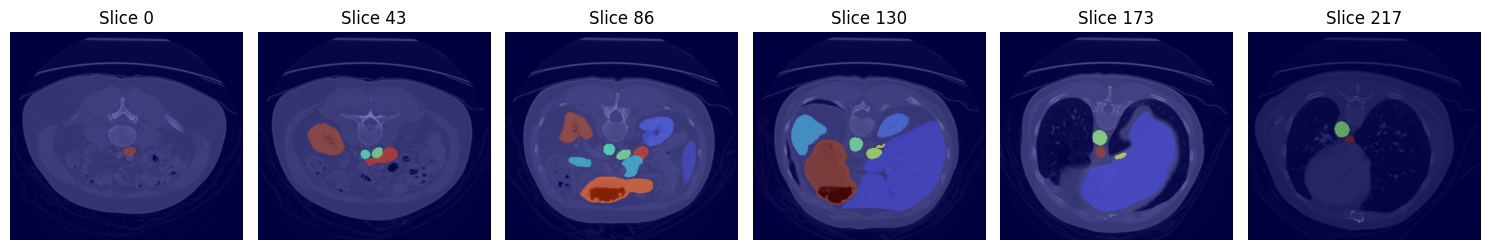

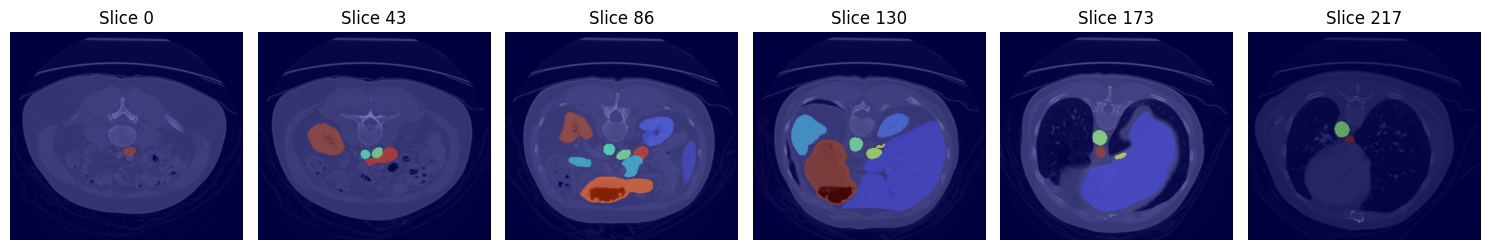

In [5]:
plot_vol_slices(img, mask[0], num_slices=6)

In [6]:
x_np, y_np, p_np, m_np, offset_list = dg.get_data_points_numpy(max_data_points=100, offset=10, max_number_labels=3)

Creating new Data Points ...
It took 3 seconds


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.827601..4.9389453].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.877715..5.0].


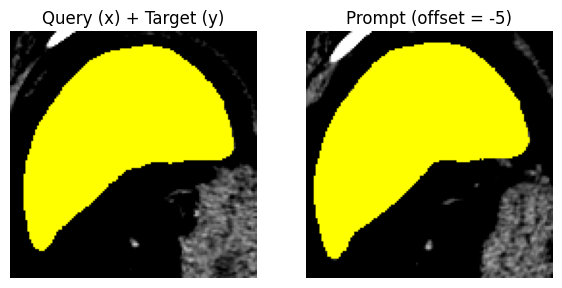

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81139743..4.0770826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8000289..4.6816077].



x: -4.827600955963135 - 4.938945293426514 | y: 0.0 - 1.0 | p (img): -4.877715110778809 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


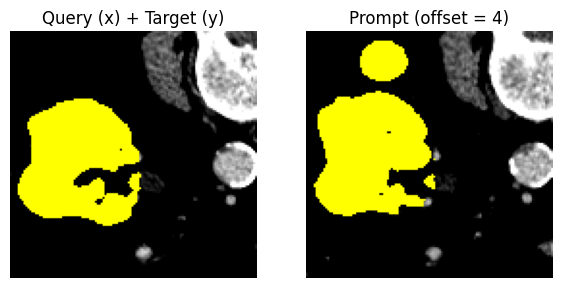

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..1.7044016].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.6015449].



x: -0.8113974332809448 - 4.077082633972168 | y: 0.0 - 1.0 | p (img): -0.800028920173645 - 4.681607723236084 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


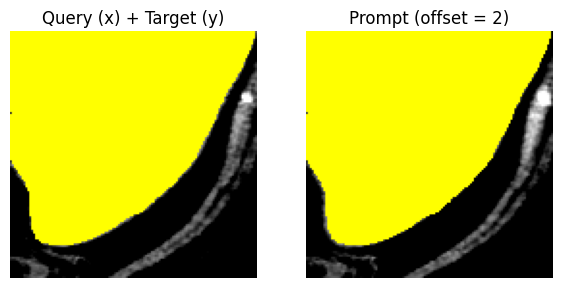

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.1545677..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8326612..5.0].



x: -5.0 - 1.7044016122817993 | y: 0.0 - 1.0 | p (img): -5.0 - 2.6015448570251465 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


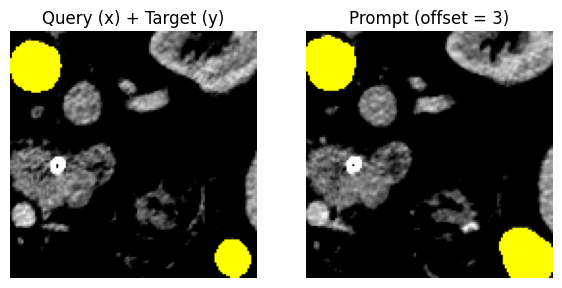

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..1.0].



x: -4.154567718505859 - 5.0 | y: 0.0 - 1.0 | p (img): -2.8326611518859863 - 5.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


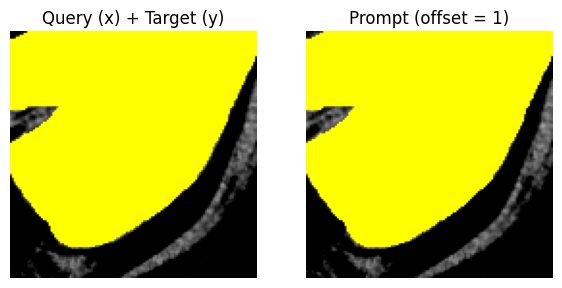

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8432245..1.7928995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.836611..1.0].



x: -5.0 - 1.0111616849899292 | y: 0.0 - 1.0 | p (img): -5.0 - 1.0243990421295166 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


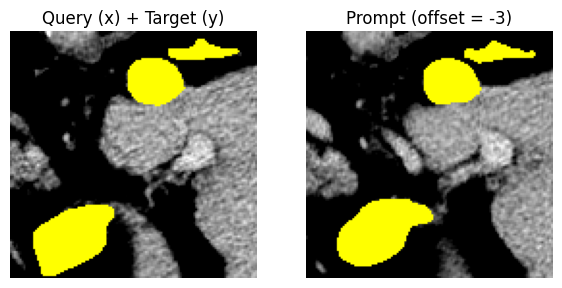


x: -4.023776054382324 - 1.792899489402771 | y: 0.0 - 1.0 | p (img): -3.1409707069396973 - 0.9646015167236328 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


In [8]:
for dp_idx in range(x_np.shape[0]):
    x, y, p = x_np[dp_idx,...], y_np[dp_idx,...], p_np[dp_idx,...]
    plot_one_dp(x,y,p, offset_list[dp_idx])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if dp_idx == 5:
        break